Maior diferença absoluta (recursivo vs iterativo): 0.0
Políticas idênticas no conjunto verificado? True


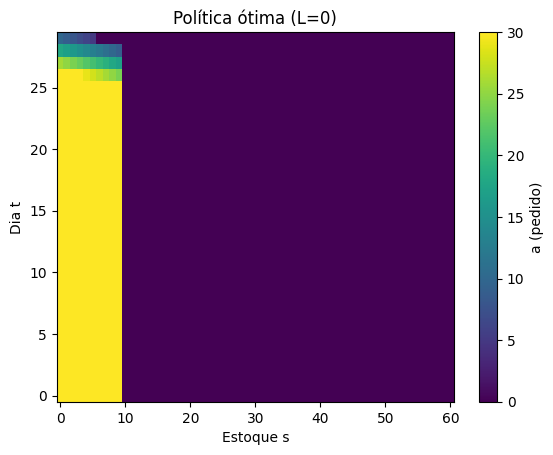

   t  s_ini  arrival   a   d  served  ruptura  s_fim  custo_dia  custo_acum
0  0     20        0   0   4       4        0     16       1.28        1.28
1  1     16        0   0  13      13        0      3       0.24        1.52
2  2      3        0  30   6       6        0     27      46.16       47.68
3  3     27        0   0  14      14        0     13       1.04       48.72
4  4     13        0   0   5       5        0      8       0.64       49.36
Maior diferença absoluta (recursivo vs iterativo): 0.0
Políticas idênticas no conjunto verificado? True
   t  s_ini  arrival   a   d  served  ruptura  s_fim  custo_dia  custo_acum
0  0     15        0   0   5       5        0     10       0.80        0.80
1  1     10        0   0   4       4        0      6       0.48        1.28
2  2      6        0  12   7       7        0     11      23.28       24.56
3  3     11       12   0   4       4        0     19       1.52       26.08
4  4     19        0   0  12      12        0      7       0

In [5]:
from dataclasses import dataclass
from functools import lru_cache
from typing import List, Tuple, Iterable
import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================
# 1) Parâmetros e utilidades
# ============================

@dataclass
class InventoryParams:
    T: int                   # horizonte (dias)
    C: int                   # capacidade máxima do estoque
    Amax: int                # pedido máximo por dia
    K: float                 # custo fixo por pedido
    c: float                 # custo unitário do pedido
    h: float                 # custo de manter 1 unid no estoque ao fim do dia
    p: float                 # penalidade por unidade faltante (lost sales)
    demand_lambda: float     # média da demanda (Poisson) se constante
    demand_lambda_vec: List[float] = None  # opcional: vetor lambda por dia
    demand_tail_epsilon: float = 1e-8      # erro máximo aceito ao truncar a cauda de Poisson
    L: int = 0                              # lead time determinístico (dias). L=0 => chega no mesmo dia.

    def lambda_t(self, t: int) -> float:
        if self.demand_lambda_vec is not None:
            return float(self.demand_lambda_vec[t])
        return float(self.demand_lambda)


def poisson_pmf(lmbda: float, k: int) -> float:
    return math.exp(-lmbda) * (lmbda ** k) / math.factorial(k)


def poisson_support_until(lmbda: float, eps: float) -> List[Tuple[int, float]]:
    """
    Gera PMF até que a massa acumulada atinja 1 - eps.
    Mais robusto que um corte "lambda + 10*sqrt(lambda)".
    """
    pmf = []
    acc = 0.0
    k = 0
    while True:
        p = poisson_pmf(lmbda, k)
        pmf.append(p)
        acc += p
        if acc >= 1 - eps:
            break
        k += 1
    s = sum(pmf)
    pmf = [p/s for p in pmf]
    return list(enumerate(pmf))


def pipeline_states(L: int, Amax: int) -> Iterable[Tuple[int, ...]]:
    if L <= 0:
        yield tuple()
    else:
        import itertools
        for tup in itertools.product(range(Amax + 1), repeat=L):
            yield tup


def push_pipeline(p: Tuple[int, ...], a: int) -> Tuple[int, ...]:
    if len(p) == 0:
        return tuple()
    return (*p[1:], int(a))


# ================================================
# 2) PD Recursiva (com memoização via @lru_cache)
# ================================================

def solve_dp_recursive(params: InventoryParams):
    T, C, Amax, L = params.T, params.C, params.Amax, params.L
    demand_supp_by_t = [poisson_support_until(params.lambda_t(t), params.demand_tail_epsilon) for t in range(T)]

    @lru_cache(maxsize=None)
    def V(t: int, s: int, pipeline: Tuple[int, ...]):
        if t == T:
            return params.h * s
        best = math.inf
        arrival = pipeline[0] if L > 0 else 0
        supp = demand_supp_by_t[t]
        for a in range(0, min(Amax, C - s) + 1):
            order_cost = (params.K if a > 0 else 0.0) + params.c * a
            pipeline_next = push_pipeline(pipeline, a) if L > 0 else tuple()
            expected = 0.0
            for d, prob in supp:
                served_cap = s + arrival + a
                served = min(served_cap, d)
                shortage = d - served
                s_next = min(C, max(0, served_cap - d))
                stage_cost = order_cost + params.h * s_next + params.p * shortage
                expected += prob * (stage_cost + V(t + 1, s_next, pipeline_next))
            best = min(best, expected)
        return best

    if L == 0:
        value = np.zeros((T + 1, C + 1), dtype=float)
        pi = np.zeros((T, C + 1), dtype=int)
        for s0 in range(C + 1):
            value[T, s0] = params.h * s0
        for t in range(T):
            supp = demand_supp_by_t[t]
            for s0 in range(C + 1):
                best = math.inf
                best_a = 0
                for a in range(0, min(Amax, C - s0) + 1):
                    order_cost = (params.K if a > 0 else 0.0) + params.c * a
                    expected = 0.0
                    for d, prob in supp:
                        served_cap = s0 + a
                        served = min(served_cap, d)
                        shortage = d - served
                        s_next = min(C, max(0, served_cap - d))
                        stage_cost = order_cost + params.h * s_next + params.p * shortage
                        expected += prob * (stage_cost + V(t + 1, s_next, tuple()))
                    if expected < best:
                        best, best_a = expected, a
                value[t, s0] = best
                pi[t, s0] = best_a
        return value, pi, V
    else:
        value = {(T, s, p): params.h * s for s in range(C + 1) for p in pipeline_states(L, Amax)}
        pi = {}
        for t in range(T - 1, -1, -1):
            supp = demand_supp_by_t[t]
            for p in pipeline_states(L, Amax):
                arrival = p[0]
                for s0 in range(C + 1):
                    best = math.inf
                    best_a = 0
                    for a in range(0, min(Amax, C - s0) + 1):
                        order_cost = (params.K if a > 0 else 0.0) + params.c * a
                        pnext = push_pipeline(p, a)
                        expected = 0.0
                        for d, prob in supp:
                            served_cap = s0 + arrival + a
                            served = min(served_cap, d)
                            shortage = d - served
                            s_next = min(C, max(0, served_cap - d))
                            stage_cost = order_cost + params.h * s_next + params.p * shortage
                            expected += prob * (stage_cost + V(t + 1, s_next, pnext))
                        if expected < best:
                            best, best_a = expected, a
                    value[(t, s0, p)] = best
                    pi[(t, s0, p)] = best_a
        return value, pi, V


# ====================================
# 3) PD Iterativa (bottom-up)
# ====================================

def solve_dp_iterative(params: InventoryParams):
    T, C, Amax, L = params.T, params.C, params.Amax, params.L
    demand_supp_by_t = [poisson_support_until(params.lambda_t(t), params.demand_tail_epsilon) for t in range(T)]

    if L == 0:
        V = np.zeros((T + 1, C + 1), dtype=float)
        pi = np.zeros((T, C + 1), dtype=int)
        for s in range(C + 1):
            V[T, s] = params.h * s
        for t in range(T - 1, -1, -1):
            supp = demand_supp_by_t[t]
            for s in range(C + 1):
                best = math.inf
                best_a = 0
                for a in range(0, min(Amax, C - s) + 1):
                    order_cost = (params.K if a > 0 else 0.0) + params.c * a
                    expected = 0.0
                    for d, prob in supp:
                        served_cap = s + a
                        served = min(served_cap, d)
                        shortage = d - served
                        s_next = min(C, max(0, served_cap - d))
                        stage_cost = order_cost + params.h * s_next + params.p * shortage
                        expected += prob * (stage_cost + V[t + 1, s_next])
                    if expected < best:
                        best, best_a = expected, a
                V[t, s] = best
                pi[t, s] = best_a
        return V, pi
    else:
        V = {(T, s, p): params.h * s for s in range(C + 1) for p in pipeline_states(L, Amax)}
        pi = {}
        for t in range(T - 1, -1, -1):
            supp = demand_supp_by_t[t]
            for p in pipeline_states(L, Amax):
                arrival = p[0]
                for s in range(C + 1):
                    best = math.inf
                    best_a = 0
                    for a in range(0, min(Amax, C - s) + 1):
                        order_cost = (params.K if a > 0 else 0.0) + params.c * a
                        pnext = push_pipeline(p, a)
                        expected = 0.0
                        for d, prob in supp:
                            served_cap = s + arrival + a
                            served = min(served_cap, d)
                            shortage = d - served
                            s_next = min(C, max(0, served_cap - d))
                            stage_cost = order_cost + params.h * s_next + params.p * shortage
                            expected += prob * (stage_cost + V[(t + 1, s_next, pnext)])
                        if expected < best:
                            best, best_a = expected, a
                    V[(t, s, p)] = best
                    pi[(t, s, p)] = best_a
        return V, pi


# ====================================
# 4) Validação | Mesmos resultados
# ====================================

def validate_equivalence(params: InventoryParams):
    V_rec, pi_rec, _ = solve_dp_recursive(params)
    V_it,  pi_it  = solve_dp_iterative(params)

    if params.L == 0:
        max_abs_diff = float(np.max(np.abs(V_rec - V_it)))
        same_policy = bool(np.array_equal(pi_rec, pi_it))
    else:
        import random
        keys = [k for k in V_rec.keys() if isinstance(k, tuple) and len(k) == 3 and k[0] < params.T]
        sample = random.sample(keys, min(300, len(keys)))
        diffs = [abs(V_rec[k] - V_it[k]) for k in sample]
        max_abs_diff = max(diffs) if diffs else 0.0
        same_policy = all(pi_rec[k] == pi_it[k] for k in sample)

    print("Maior diferença absoluta (recursivo vs iterativo):", max_abs_diff)
    print("Políticas idênticas no conjunto verificado?", same_policy)
    return V_rec, pi_rec, V_it, pi_it


# ====================================
# 5) Visualização e análise
# ====================================

def plot_policy_heatmap(pi: np.ndarray, title: str = "Política ótima (a = quantidade a pedir)"):
    if not isinstance(pi, np.ndarray):
        raise ValueError("Heatmap disponível apenas para L=0.")
    plt.figure()
    plt.imshow(pi, aspect='auto', origin='lower')
    plt.title(title)
    plt.xlabel("Estoque s")
    plt.ylabel("Dia t")
    plt.colorbar(label="a (pedido)")
    plt.show()


_rng = np.random.default_rng(123)

def simulate_policy(params: InventoryParams, policy, s0: int, n_runs: int = 1, pipeline0: Tuple[int, ...] = None):
    L = params.L
    if L > 0 and pipeline0 is None:
        pipeline0 = tuple(0 for _ in range(L))

    history = []
    for run in range(n_runs):
        s = int(s0)
        p = pipeline0 if L > 0 else tuple()
        total_cost = 0.0
        log = []
        for t in range(params.T):
            a = policy[(t, s, p)] if L > 0 else int(policy[t, s])
            arrival = p[0] if L > 0 else 0
            d = int(_rng.poisson(params.lambda_t(t)))
            order_cost = (params.K if a > 0 else 0.0) + params.c * a
            served_cap = s + arrival + a
            served = min(served_cap, d)
            shortage = d - served
            s_next = min(params.C, max(0, served_cap - d))
            stage_cost = order_cost + params.h * s_next + params.p * shortage
            total_cost += stage_cost

            log.append({
                "t": t, "s_ini": s, "arrival": arrival, "a": a, "d": d,
                "served": served, "ruptura": shortage, "s_fim": s_next,
                "custo_dia": stage_cost, "custo_acum": total_cost
            })
            s = s_next
            p = push_pipeline(p, a) if L > 0 else tuple()
        history.append(pd.DataFrame(log))
    return history if n_runs > 1 else history[0]


def sensitivity_sweep(params: InventoryParams, grid_K: List[float], grid_p: List[float]):
    if params.L != 0:
        raise ValueError("Sweep implementado somente para L=0.")
    rows = []
    for K in grid_K:
        for p in grid_p:
            test = InventoryParams(**{**params.__dict__, "K": K, "p": p})
            V, pi = solve_dp_iterative(test)
            rows.append({"K": K, "p": p, "V_0_s0": float(V[0, 0])})
    return pd.DataFrame(rows)


# ==============================
# 6) Exemplo guiado
# ==============================
if __name__ == "__main__":
    params = InventoryParams(
        T=30, C=60, Amax=30,
        K=8.0, c=1.2, h=0.08, p=6.0,
        demand_lambda=8.0, demand_lambda_vec=None,
        demand_tail_epsilon=1e-8, L=0
    )
    V_rec, pi_rec, V_it, pi_it = validate_equivalence(params)
    plot_policy_heatmap(pi_it, "Política ótima (L=0)")
    sim0 = simulate_policy(params, pi_it, s0=20)
    print(sim0.head())

    params_L1 = InventoryParams(
        T=15, C=40, Amax=12,
        K=8.0, c=1.2, h=0.08, p=6.0,
        demand_lambda=7.5, demand_tail_epsilon=1e-7, L=1
    )
    V_rec1, pi_rec1, V_it1, pi_it1 = validate_equivalence(params_L1)
    sim1 = simulate_policy(params_L1, pi_it1, s0=15, pipeline0=(0,))
    print(sim1.head())

    df_sens = sensitivity_sweep(params, grid_K=[4,8,12], grid_p=[3,6,9])
    print("\nSensibilidade (mostrando 5 linhas):")
    print(df_sens.head())


In [ ]:
import time
import numpy as np

params = InventoryParams(
    T=30, C=60, Amax=30,
    K=8.0, c=1.2, h=0.08, p=6.0,
    demand_lambda=8.0, demand_lambda_vec=None,
    demand_tail_epsilon=1e-8, L=0
)

_ = solve_dp_iterative(params)

t0 = time.perf_counter()
V_rec, pi_rec, _ = solve_dp_recursive(params)
t1 = time.perf_counter()
print(f"Tempo (recursiva): {t1 - t0:.4f}s")

t0 = time.perf_counter()
V_it, pi_it = solve_dp_iterative(params)
t1 = time.perf_counter()
print(f"Tempo (iterativa): {t1 - t0:.4f}s")

iguais = np.allclose(V_rec, V_it) and np.array_equal(pi_rec, pi_it)
print("Resultados iguais? ", iguais)


Tempo (recursiva): 0.6225s
Tempo (iterativa): 0.4438s
Resultados iguais?  True
